In [42]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

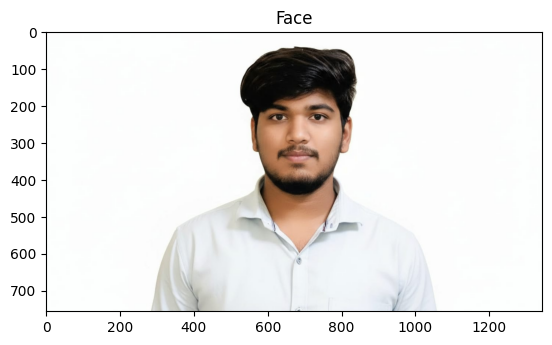

In [43]:
# Load the Face Image
faceImage = cv2.imread('img.jpeg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [44]:
faceImage.shape

(756, 1344, 3)

In [45]:
#resized_faceImage.shape
faceImage.shape

(756, 1344, 3)

Text(0.5, 1.0, 'glassPNG')

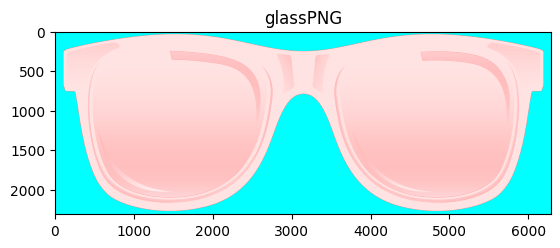

In [46]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('glass.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

Resized Glass: (50, 190, 4)


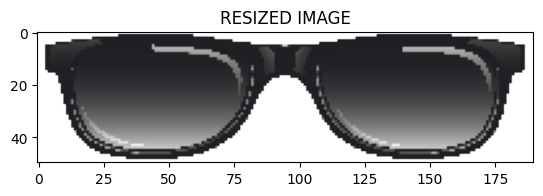

In [47]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG, (190, 50))
print("Resized Glass:", glassPNG.shape)
plt.imshow(glassPNG)
plt.title("RESIZED IMAGE")
plt.show()

In [48]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:, :, :3]   # color
glassMask1 = glassPNG[:, :, 3]  # alpha


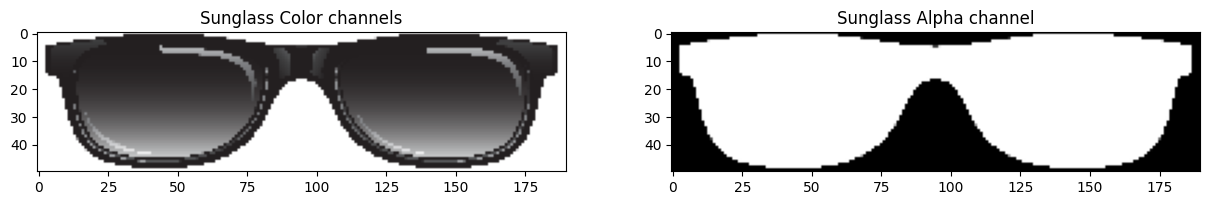

In [49]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

(np.float64(-0.5), np.float64(1343.5), np.float64(755.5), np.float64(-0.5))

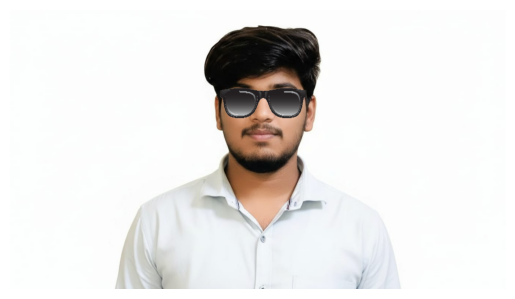

In [65]:
face = cv2.imread("img.jpeg")

glassNew = cv2.resize(glassPNG, (240, 85))

glassBGR = glassNew[:, :, :3]
glassMask = glassNew[:, :, 3]
glassMask = cv2.merge([glassMask]*3) / 255.0

y1, y2 = 210, 295
x1 = 566
x2 = x1 + 240   

roi = face[y1:y2, x1:x2]

roi_bg = roi * (1 - glassMask)
roi_fg = glassBGR * glassMask

result = roi_bg + roi_fg

face[y1:y2, x1:x2] = result.astype(np.uint8)

plt.imshow(face[:,:,::-1])
plt.axis("off")

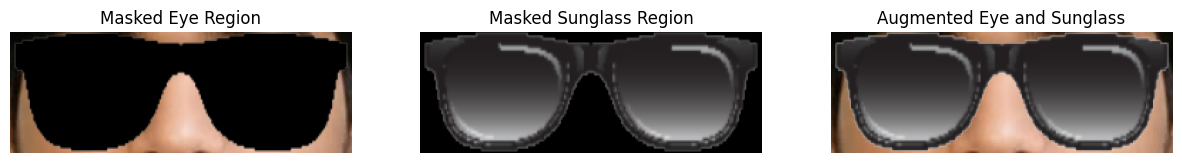

In [71]:
# Copy fresh image
faceWithGlassesArithmetic = face.copy()

# ROI (IMPORTANT: use correct fitted coordinates)
y1, y2 = 210, 295
x1 = 566
x2 = x1 + 240

eyeROI = faceWithGlassesArithmetic[y1:y2, x1:x2]

# Resize glass + mask to ROI size
h, w, _ = eyeROI.shape
glassBGR_resized = cv2.resize(glassBGR, (w, h))
glassMask1_resized = cv2.resize(glassMask1, (w, h))

# Convert mask to 3 channel
glassMask = cv2.merge((glassMask1_resized, glassMask1_resized, glassMask1_resized))

# Normalize
glassMask = glassMask / 255.0

# Convert to float
eyeROI = eyeROI.astype(float)
glassBGR_resized = glassBGR_resized.astype(float)

# Mask operations
maskedEye = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glassBGR_resized, glassMask)

# Combine
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Convert back
eyeRoiFinal = np.uint8(eyeRoiFinal)

# Replace ROI
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeRoiFinal

# DISPLAY LIKE YOUR SCREENSHOT
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(maskedEye.astype(np.uint8)[:,:,::-1])
plt.title("Masked Eye Region")
plt.axis("off")

plt.subplot(132)
plt.imshow(maskedGlass.astype(np.uint8)[:,:,::-1])
plt.title("Masked Sunglass Region")
plt.axis("off")

plt.subplot(133)
plt.imshow(eyeRoiFinal[:,:,::-1])
plt.title("Augmented Eye and Sunglass")
plt.axis("off")

plt.show()

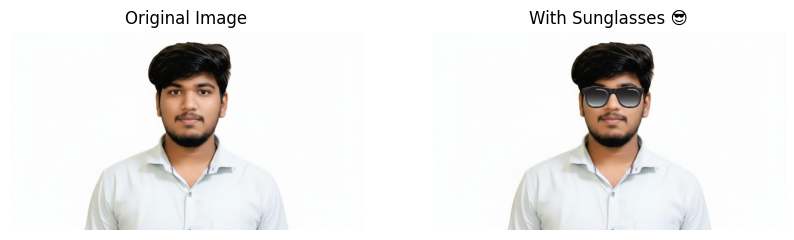

In [73]:
# ✅ SAME coordinates use pannu (important 🔥)
y1, y2 = 210, 295
x1 = 566
x2 = x1 + 240

# Replace ROI correctly
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeRoiFinal
og=cv2.imread("img.jpeg")
# Display final result
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(og[:,:,::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(faceWithGlassesArithmetic[:,:,::-1])
plt.title("With Sunglasses 😎")
plt.axis("off")

plt.show()